In [8]:
import pandas as pd

m2or_data = pd.read_csv('../data/datasets/M2OR_sample_weights_pairs.csv', sep=";")
m2or_seqs_annotated = pd.read_csv('../data/datasets/M2OR/seqs_with_annotations.csv', sep=";")
m2or_seqs_annotated.head()

m2or_seqs_annotated


,seq_id,Mutation,Uniprot ID,_Sequence,mutated_Sequence,uniprot_id,gene_id
0,s_0,NaN,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,Q8NGN2,OR10S1
1,s_1,NaN,A0A140T8K4,MTEDNYSLTTEFILIGFSDHPDLKILLFLVLSTIYLVTMVGNLGLV...,MTEDNYSLTTEFILIGFSDHPDLKILLFLVLSTIYLVTMVGNLGLV...,NaN,NaN
2,s_2,NaN,Q8VFV4,MPGGRNSTVITKFILVGFSDFPKLKLVLFVIFLGSYLSTVVWNLGL...,MPGGRNSTVITKFILVGFSDFPKLKLVLFVIFLGSYLSTVVWNLGL...,NaN,NaN
3,s_3,NaN,Q8NGT9,MGENQTMVTEFLLLGFLLGPRIQMLLFGLFSLFYIFTLLGNGAILG...,MGENQTMVTEFLLLGFLLGPRIQMLLFGLFSLFYIFTLLGNGAILG...,Q8NGT9,OR2A1
4,s_4,NaN,Q96R45,MGDNITSITEFLLLGFPVGPRIQMLLFGLFSLFYVFTLLGNGTILG...,MGDNITSITEFLLLGFPVGPRIQMLLFGLFSLFYVFTLLGNGTILG...,Q96R45,OR2A7
...,...,...,...,...,...,...,...
1232,s_1232,NaN,Q8VGX3,MIFSNNSHLLPHTFFLTGIPGLTAAHVWISLPFCFMFVLSLTGNAV...,MIFSNNSHLLPHTFFLTGIPGLTAAHVWISLPFCFMFVLSLTGNAV...,NaN,NaN
1233,s_1233,NaN,E9PZ66,MTALSVTNYTSSRFALTGFPGLEIYYFWISVPFFIIYVTVFLGNCM...,MTALSVTNYTSSRFALTGFPGLEIYYFWISVPFFIIYVTVFLGNCM...,NaN,NaN
1234,s_1234,NaN,Q7TRR8,MSIFNLSVTEVSTFHLVGFPGMESAHIWIFIPICLLYTVAILGNCT...,MSIFNLSVTEVSTFHLVGFPGMESAHIWIFIPICLLYTVAILGNCT...,NaN,NaN
1235,s_1235,NaN,Q8VH16,MLVKSSIMSVLNSSEIEITTFFLIGIPGLEYAHAWISIPICLMYLV...,MLVKSSIMSVLNSSEIEITTFFLIGIPGLEYAHAWISIPICLMYLV...,NaN,NaN


In [10]:
# get all seq_id's of rows with beginning with "OR2J" in column "gene_id"
or2j_seq_ids = m2or_seqs_annotated[m2or_seqs_annotated['gene_id'].str.startswith('OR2J', na=False)]['seq_id'].tolist()
print(f"Found {len(or2j_seq_ids)} sequences with gene_id starting with 'OR2J'")
print("Seq IDs:", or2j_seq_ids)


Found 18 sequences with gene_id starting with 'OR2J'
Seq IDs: ['s_57', 's_194', 's_261', 's_323', 's_324', 's_325', 's_482', 's_542', 's_561', 's_562', 's_563', 's_612', 's_613', 's_615', 's_616', 's_619', 's_625', 's_654']


In [11]:
# now gather all data in m2or_data with rows matching the seq_ids belonging to OR2J sequences
or2j_data = m2or_data[m2or_data['seq_id'].isin(or2j_seq_ids)]
print(f"Found {len(or2j_data)} rows in M2OR dataset for OR2J subfamily sequences")
print(f"Shape of OR2J subset: {or2j_data.shape}")
or2j_data.head()


Found 472 rows in M2OR dataset for OR2J subfamily sequences
Shape of OR2J subset: (472, 11)


,mol_id,seq_id,Responsive,_DataQuality,num_unique_value_screen,canonicalSMILES,mutated_Sequence,weight_quality,weight_class,weight_pair_imbalance,sample_weight
109,m_1,s_323,0,ec50,NaN,CC1=CCC(CC1=O)C(=C)C,MMIKKNASSEDFFILLGFSNWPQLEVVLFVVILIFYLMTLTGNLFI...,1.0,1.000000,0.321361,0.321361
134,m_100,s_482,0,ec50,NaN,C1CCCCCC(=O)OCCOC(=O)CCCCC1,MNDDGKVNASSEGYFILVGFSNWPHLEVVIFVVVLIFYLMTLIGNL...,1.0,1.000000,0.352061,0.352061
135,m_100,s_561,1,ec50,NaN,C1CCCCCC(=O)OCCOC(=O)CCCCC1,MNDDGKVNASSEGYFILVGFSNWPHLEVVIFVVVLIFYLMTLIGNL...,1.0,15.056207,1.988470,29.938812
136,m_100,s_563,0,ec50,NaN,C1CCCCCC(=O)OCCOC(=O)CCCCC1,MNDDGKVNASSEGYFILVGFSNWPHLEVVIFVVVLIFYLMTLIGNL...,1.0,1.000000,1.988470,1.988470
217,m_102,s_323,0,ec50,NaN,CC1(C2CCC(C2)(C1=O)C)C,MMIKKNASSEDFFILLGFSNWPQLEVVLFVVILIFYLMTLTGNLFI...,1.0,1.000000,0.230553,0.230553


In [12]:
or2j_data["Responsive"].value_counts()

Responsive
0    393
1     79
Name: count, dtype: int64

In [13]:
or2j_data['_DataQuality'].value_counts()

_DataQuality
primaryScreening      337
ec50                  116
secondaryScreening     19
Name: count, dtype: int64

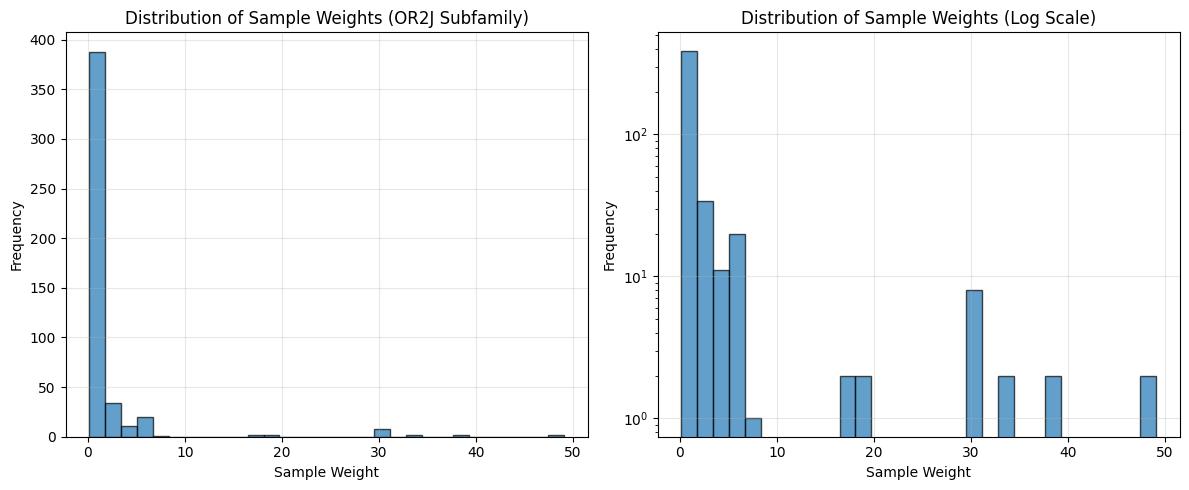

Sample weight statistics for OR2J subfamily:
Mean: 1.9917
Median: 0.2877
Min: 0.1549
Max: 49.0854
Standard deviation: 6.2088


In [15]:
# plot distribution of sample weights

import matplotlib.pyplot as plt
import numpy as np

# Plot distribution of sample weights
plt.figure(figsize=(12, 5))

# Subplot 1: Histogram of all sample weights
plt.subplot(1, 2, 1)
plt.hist(or2j_data['sample_weight'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Sample Weight')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Weights (OR2J Subfamily)')
plt.grid(True, alpha=0.3)

# Subplot 2: Log-scale histogram for better visualization of range
plt.subplot(1, 2, 2)
plt.hist(or2j_data['sample_weight'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Sample Weight')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Weights (Log Scale)')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Sample weight statistics for OR2J subfamily:")
print(f"Mean: {or2j_data['sample_weight'].mean():.4f}")
print(f"Median: {or2j_data['sample_weight'].median():.4f}")
print(f"Min: {or2j_data['sample_weight'].min():.4f}")
print(f"Max: {or2j_data['sample_weight'].max():.4f}")
print(f"Standard deviation: {or2j_data['sample_weight'].std():.4f}")
